In [24]:
from abc import ABC, abstractmethod
from dataclasses import dataclass
from collections import deque
from typing import Any, Dict, Iterable, List, Optional, Tuple
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [3]:
class Problem(ABC):
    """Abstract base class for a search problem."""

    @abstractmethod
    def initial_state(self) -> Any:
        """Return the start state."""
        pass

    @abstractmethod
    def is_goal(self, state: Any) -> bool:
        """Return True if state is a goal state."""
        pass

    @abstractmethod
    def actions(self, state: Any) -> List[Any]:
        """Return the legal actions available in the given state."""
        pass

    @abstractmethod
    def result(self, state: Any, action: Any) -> Any:
        """Return the next state after applying action in state."""
        pass

    @abstractmethod
    def action_cost(self, state: Any, action: Any, next_state: Any) -> float:
        """Return the cost of applying action in state to reach next_state."""
        pass

In [4]:
@dataclass
class Node:
    state: Any
    parent: Optional["Node"] = None
    action: Optional[Any] = None
    path_cost: float = 0
    depth: int = 0

    def __post_init__(self):
        if self.parent is not None:
            self.depth = self.parent.depth + 1


@dataclass
class SearchResult:
    algorithm: str
    status: str
    solution: Optional[Node]
    nodes_expanded: int
    max_frontier_size: int
    reached_count: int = 0
    limit: Optional[int] = None
    iterations: Optional[List[Dict[str, Any]]] = None

    @property
    def path(self) -> Optional[List[Any]]:
        if self.solution is None:
            return None
        return reconstruct_path(self.solution)

    @property
    def solution_depth(self) -> Optional[int]:
        if self.solution is None:
            return None
        return self.solution.depth

    @property
    def solution_cost(self) -> Optional[float]:
        if self.solution is None:
            return None
        return self.solution.path_cost

In [5]:
def reconstruct_path(node: Node) -> List[Any]:
    """Return the list of states from the root node to this node."""
    path = []

    while node is not None:
        path.append(node.state)
        node = node.parent

    path.reverse()
    return path


def reconstruct_actions(node: Node) -> List[Any]:
    """Return the list of actions from the root node to this node."""
    actions = []

    while node is not None and node.parent is not None:
        actions.append(node.action)
        node = node.parent

    actions.reverse()
    return actions


def state_is_on_path(node: Node, state: Any) -> bool:
    """
    Return True if state already appears on the path from the root to node.

    This is useful for depth-limited search because DLS often uses path-cycle
    checking instead of a global reached set.
    """
    while node is not None:
        if node.state == state:
            return True
        node = node.parent

    return False


def result_to_row(result: SearchResult) -> Dict[str, Any]:
    """Convert a SearchResult object into a row for a pandas DataFrame."""
    return {
        "Algorithm": result.algorithm,
        "Status": result.status,
        "Limit": result.limit,
        "Solution depth": result.solution_depth,
        "Solution cost": result.solution_cost,
        "Nodes expanded": result.nodes_expanded,
        "Max frontier/stack": result.max_frontier_size,
        "Reached states": result.reached_count,
    }


def show_results(results: List[SearchResult]) -> pd.DataFrame:
    """Display results as a DataFrame."""
    return pd.DataFrame([result_to_row(r) for r in results])

In [ ]:
MOVES = {
    "UP": (-1, 0),
    "DOWN": (1, 0),
    "LEFT": (0, -1),
    "RIGHT": (0, 1),
}


class GridProblem(Problem):
    def __init__(
        self,
        grid: List[List[int]],
        start: Tuple[int, int],
        goal: Tuple[int, int],
    ):
        """
        grid:
            2D list where 0 = free cell and 1 = obstacle.

        start, goal:
            Tuples in the form (row, col).
        """
        self.grid = grid
        self.start = start
        self.goal = goal

        self.rows = len(grid)
        self.cols = len(grid[0])

    def initial_state(self) -> Tuple[int, int]:
        return self.start

    def is_goal(self, state: Tuple[int, int]) -> bool:
        # TODO 1:
        if state == self.goal:
            return True
        else:
            return False

    def in_bounds(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return 0 <= row < self.rows and 0 <= col < self.cols

    def is_free(self, state: Tuple[int, int]) -> bool:
        row, col = state
        return self.grid[row][col] == 0

    def actions(self, state: Tuple[int, int]) -> List[str]:
        # TODO 2:
        legal_actions = []
        for action in MOVES:
            row_direction,column_direction = MOVES[action]
            row,col = state
            neighbour = (row_direction + row,column_direction + col)
            if (self.in_bounds(neighbour)) and (self.is_free(neighbour)):
                legal_actions.append(action)
        return legal_actions
    def result(self, state: Tuple[int, int], action: str) -> Tuple[int, int]:
        # TODO 3:
        return (state[0] + MOVES[action][0], state[1] + MOVES[action][1])
    def action_cost(
        self,
        state: Tuple[int, int],
        action: str,
        next_state: Tuple[int, int],
    ) -> float:
        # TODO 4:
        return 1

In [7]:
test_grid = [
    [0, 0, 0],
    [1, 1, 0],
    [0, 0, 0],
]

test_problem = GridProblem(test_grid, start=(0, 0), goal=(2, 2))

assert test_problem.initial_state() == (0, 0)
assert test_problem.is_goal((2, 2)) is True
assert test_problem.is_goal((0, 0)) is False
assert test_problem.actions((0, 0)) == ["RIGHT"]
assert test_problem.result((0, 0), "RIGHT") == (0, 1)
assert test_problem.action_cost((0, 0), "RIGHT", (0, 1)) == 1

print("GridProblem self-check passed.")

GridProblem self-check passed.


In [8]:
sample_grid = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 1, 0, 1, 1],
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [0, 1, 1, 0, 1, 1, 1, 1, 1, 0],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [1, 0, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [0, 1, 1, 1, 1, 0, 0, 0, 1, 0],
]

start = (0, 0)
goal = (9, 9)

problem = GridProblem(sample_grid, start, goal)

In [9]:
def plot_path(
    grid: List[List[int]],
    start: Optional[Tuple[int, int]] = None,
    goal: Optional[Tuple[int, int]] = None,
    path: Optional[List[Tuple[int, int]]] = None,
    terrain_costs: Optional[List[List[float]]] = None,
    title: str = "Grid Map",
):
    """Visualise a grid and, optionally, a solution path."""
    arr = np.array(grid)
    height, width = arr.shape

    path_set = set(path) if path is not None else set()

    fig, ax = plt.subplots(figsize=(7, 7))
    ax.set_xlim(0, width)
    ax.set_ylim(height, 0)
    ax.set_aspect("equal")
    ax.axis("off")
    ax.set_title(title)

    for row in range(height):
        for col in range(width):
            state = (row, col)

            if arr[row, col] == 1:
                fill = (0.15, 0.15, 0.15)
            elif start is not None and state == start:
                fill = (0.95, 0.20, 0.20)
            elif goal is not None and state == goal:
                fill = (0.20, 0.70, 0.25)
            elif state in path_set:
                fill = (0.95, 0.90, 0.35)
            else:
                fill = (0.95, 0.95, 0.95)

            rect = patches.Rectangle(
                (col, row),
                1,
                1,
                linewidth=1,
                edgecolor=(0.75, 0.75, 0.75),
                facecolor=fill,
            )
            ax.add_patch(rect)

            if terrain_costs is not None and arr[row, col] == 0:
                ax.text(
                    col + 0.5,
                    row + 0.5,
                    str(terrain_costs[row][col]),
                    ha="center",
                    va="center",
                    fontsize=8,
                )

    plt.show()

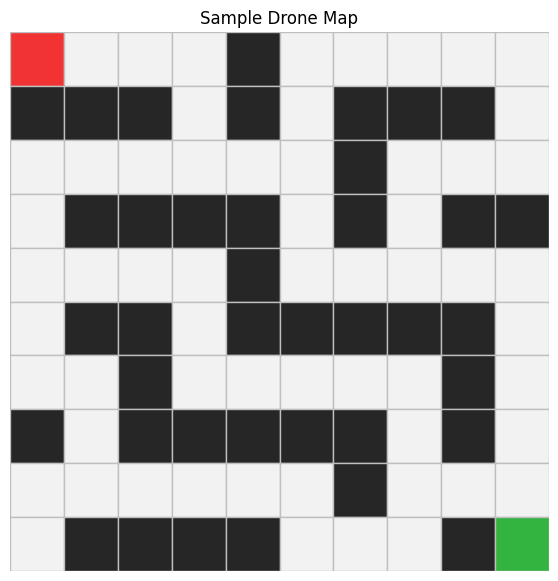

In [10]:
plot_path(sample_grid, start, goal, title="Sample Drone Map")

In [11]:
class SearchAlgorithm(ABC):
    """Base class for search algorithms."""

    def expand(self, problem: Problem, node: Node) -> Iterable[Node]:
        # TODO 5:
        s = node.state
        for action in problem.actions(s):
            s_prime = problem.result(s,action)
            cost = node.path_cost + problem.action_cost(s,action,s_prime)
            yield Node(state=s_prime, parent=node, action=action, path_cost=cost)

    @abstractmethod
    def search(self, problem: Problem) -> SearchResult:
        pass

In [12]:
class BreadthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "BFS"

        # TODO 6:
        # Implement BFS graph search using a FIFO queue.
        #
        # Steps:
        # 1. Create the initial node from problem.initial_state().
        # 2. If the initial state is the goal, return success.
        # 3. Create a deque frontier and add the initial node.
        # 4. Create a reached set and add the initial state.
        # 5. While frontier is not empty:
        #       a. pop from the LEFT of the deque.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. for each child:
        #            i. if child is goal, return success.
        #           ii. if child.state is not in reached:
        #                  add child.state to reached.
        #                  append child to frontier.
        #       e. update max_frontier_size.
        # 6. Return failure if no solution is found.
        #
        # Hint:
        # frontier = deque([node])
        # node = frontier.popleft()
        node = Node(state=problem.initial_state())
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm= algorithm,
                status= "success",
                solution= node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=0,
                limit=None,
                iterations=None
            )
        frontier = deque([node])
        reached = {node.state}
        nodes_expanded = 0
        max_frontier_size = 1
        while frontier:
            node = frontier.popleft()
            nodes_expanded += 1
            for child in self.expand(problem, node):
                if problem.is_goal(child.state):
                    return SearchResult(
                        algorithm= algorithm,
                        status= "success",
                        solution= child,
                        nodes_expanded=nodes_expanded,
                        max_frontier_size=len(frontier),
                        reached_count=len(reached),
                        limit=None,
                        iterations=None
                    )
                if child.state not in reached:
                    reached.add(child.state)
                    frontier.append(child)
            max_frontier_size = max(max_frontier_size, len(frontier))
        return SearchResult(
            algorithm= algorithm,
            status= "failure",
            solution= None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
            limit=None,
            iterations=None
        )

In [13]:
class DepthFirstSearch(SearchAlgorithm):
    def search(self, problem: Problem) -> SearchResult:
        algorithm = "DFS"

        # TODO 7:
        # Implement DFS graph search using a stack.
        #
        # Steps:
        # 1. Create the initial node.
        # 2. If the initial state is the goal, return success.
        # 3. Use a Python list as the stack frontier.
        # 4. Use a reached set.
        # 5. While frontier is not empty:
        #       a. pop from the end of the list.
        #       b. increment nodes_expanded.
        #       c. expand the node.
        #       d. add unreached children to the stack.
        #       e. update max_frontier_size.
        #
        # Note:
        # If you want DFS to explore actions in the same order as MOVES,
        # you may need to reverse the children before pushing them.
        node = Node(state=problem.initial_state())
        if problem.is_goal(node.state):
            return SearchResult(
                algorithm= algorithm,
                status= "success",
                solution= node,
                nodes_expanded=0,
                max_frontier_size=1,
                reached_count=0,
                limit=None,
                iterations=None
            )
        frontier = [node]
        reached = {node.state}
        nodes_expanded = 0
        max_frontier_size = 1
        while frontier:
            node = frontier.pop()
            nodes_expanded += 1
            for child in self.expand(problem,node):
                    if problem.is_goal(child.state):
                        return SearchResult(
                            algorithm= algorithm,
                            status= "success",
                            solution= child,
                            nodes_expanded=nodes_expanded,
                            max_frontier_size=len(frontier),
                            reached_count=len(reached),
                            limit=None,
                            iterations=None
                        )
                    if child.state not in reached:
                        reached.add(child.state)
                        frontier.append(child)
                        max_frontier_size = max(max_frontier_size,len(frontier))
        return SearchResult(
            algorithm= algorithm,
            status= "failure",
            solution= None,
            nodes_expanded=nodes_expanded,
            max_frontier_size=max_frontier_size,
            reached_count=len(reached),
            limit=None,
            iterations=None
        )


In [14]:
class DepthLimitedSearch(SearchAlgorithm):
    def search(self, problem: Problem, limit: int = 10) -> SearchResult:
        algorithm = "DLS"

        initial_node = Node(problem.initial_state())

        metrics = {
            "nodes_expanded": 0,
            "max_stack_size": 1,
        }

        solution, status = self._recursive_dls(
            problem=problem,
            node=initial_node,
            limit=limit,
            metrics=metrics,
            current_stack_size=1,
        )

        return SearchResult(
            algorithm=algorithm,
            status=status,
            solution=solution,
            nodes_expanded=metrics["nodes_expanded"],
            max_frontier_size=metrics["max_stack_size"],
            reached_count=0,
            limit=limit,
        )

    def _recursive_dls(
        self,
        problem: Problem,
        node: Node,
        limit: int,
        metrics: Dict[str, int],
        current_stack_size: int,
    ) -> Tuple[Optional[Node], str]:
        # TODO 8:
        # Implement recursive depth-limited search.
        #
        # Steps:
        # 1. If node.state is goal, return (node, "success").
        # 2. Else if node.depth >= limit, return (None, "cutoff").
        # 3. Otherwise:
        #       a. increment metrics["nodes_expanded"].
        #       b. set cutoff_occurred = False.
        #       c. for each child in expand(problem, node):
        #             i. skip the child if child.state already appears on the current path.
        #            ii. update max_stack_size.
        #           iii. recursively call _recursive_dls on the child.
        #            iv. if result is "success", return success immediately.
        #             v. if result is "cutoff", set cutoff_occurred = True.
        #       d. after all children:
        #             if cutoff_occurred, return (None, "cutoff")
        #             else return (None, "failure")
        if problem.is_goal(node.state):
            return (node, "success")
        elif node.depth >= limit:
            return (None, "cutoff")
        else:
            metrics["nodes_expanded"] += 1
            cutoff_occured = False
            for child in self.expand(problem, node):
                if state_is_on_path(node, child.state):
                    continue
                result, status = self._recursive_dls(
                    problem=problem,
                    node=child,
                    limit=limit,
                    metrics=metrics,
                    current_stack_size=current_stack_size + 1,
                )
                if status == "success":
                    return (result, "success")
                elif status == "cutoff":
                    cutoff_occured = True
                metrics["max_stack_size"] = max(metrics["max_stack_size"], current_stack_size)
            if cutoff_occured:
                return (None, "cutoff")
            else:
                return (None, "failure")

        raise NotImplementedError("Complete DepthLimitedSearch._recursive_dls")

In [15]:
class IterativeDeepeningSearch(SearchAlgorithm):
    def search(self, problem: Problem, max_depth: int = 50) -> SearchResult:
        algorithm = "IDS"

        # TODO 9:
        # Implement IDS by repeatedly running DLS from limit 0 to max_depth.
        #
        # Requirements:
        # 1. Keep a list called iteration_log.
        # 2. Accumulate total nodes expanded across all DLS iterations.
        # 3. Track the maximum stack size seen in any DLS run.
        # 4. If a DLS run returns success, return a SearchResult for IDS.
        # 5. If a DLS run returns failure, IDS can stop early and return failure.
        # 6. If all limits return cutoff up to max_depth, return cutoff.
        #
        # Hint:
        # dls = DepthLimitedSearch()
        # result = dls.search(problem, limit=limit)
        iteration_log = []
        total_nodes_expanded = 0
        max_stack_size = 0
        for limit in range(max_depth + 1):
            dls = DepthLimitedSearch()
            result = dls.search(problem, limit=limit)
            iteration_log.append({
                "limit": limit,
                "status": result.status,
                "nodes_expanded": result.nodes_expanded,
                "max_stack_size": result.max_frontier_size,
            })
            total_nodes_expanded += result.nodes_expanded
            max_stack_size = max(max_stack_size, result.max_frontier_size)
            if result.status == "success":
                return SearchResult(
                    algorithm=algorithm,
                    status="success",
                    solution=result.solution,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log,
                )
            elif result.status == "failure":
                return SearchResult(
                    algorithm=algorithm,
                    status="failure",
                    solution=None,
                    nodes_expanded=total_nodes_expanded,
                    max_frontier_size=max_stack_size,
                    reached_count=0,
                    limit=limit,
                    iterations=iteration_log,
                )
        return SearchResult(
            algorithm=algorithm,
            status="cutoff",
            solution=None,
            nodes_expanded=total_nodes_expanded,
            max_frontier_size=max_stack_size,
            reached_count=0,
            limit=max_depth,
            iterations=iteration_log,
        )

In [16]:
bfs = BreadthFirstSearch()
dfs = DepthFirstSearch()
dls = DepthLimitedSearch()
ids = IterativeDeepeningSearch()

results = [
    bfs.search(problem),
    dfs.search(problem),
    dls.search(problem, limit=10),
    ids.search(problem, max_depth=30),
]

show_results(results)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18.0,18.0,50,2,52
1,DFS,success,NaN,18.0,18.0,18,3,21
2,DLS,cutoff,10.0,NaN,NaN,16,10,0
3,IDS,success,18.0,18.0,18.0,356,18,0


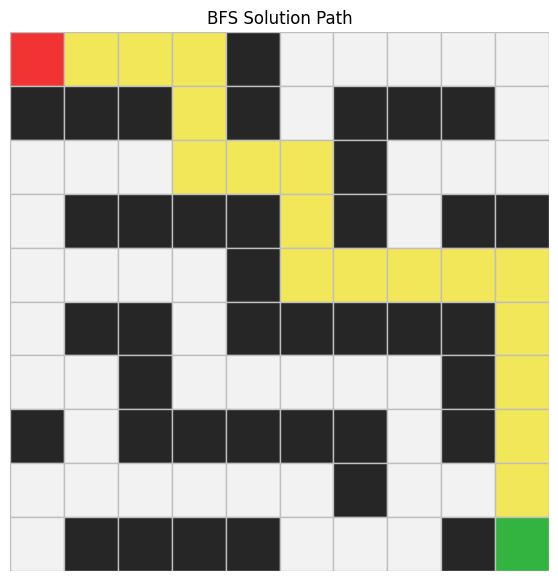

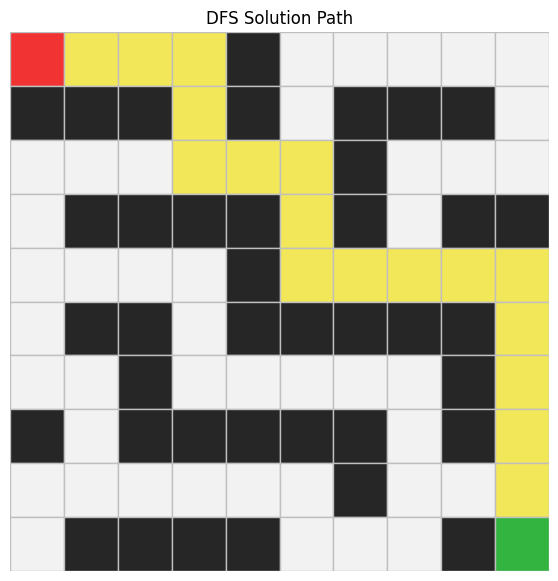

In [17]:
# Visualise solution paths.
# After your algorithms work, choose at least two algorithms and plot their paths.

bfs_result = results[0]
dfs_result = results[1]

plot_path(
    sample_grid,
    start,
    goal,
    path=bfs_result.path,
    title="BFS Solution Path",
)

plot_path(
    sample_grid,
    start,
    goal,
    path=dfs_result.path,
    title="DFS Solution Path",
)

In [18]:
# TODO 10:
# Create your first custom map here.

custom_grid_1 = [
    [0, 0, 0, 0, 1, 0, 0, 0, 0, 0],
    [1, 1, 1, 0, 1, 0, 1, 1, 1, 1],
    [0, 0, 1, 0, 0, 0, 0, 0, 1, 0],
    [0, 1, 1, 1, 1, 1, 1, 0, 1, 0],
    [0, 0, 0, 0, 0, 0, 1, 0, 0, 0],
    [1, 1, 1, 1, 1, 0, 1, 1, 1, 0],
    [0, 0, 0, 0, 1, 0, 0, 0, 1, 0],
    [0, 1, 1, 0, 1, 1, 1, 0, 1, 0],
    [0, 0, 1, 0, 0, 0, 1, 0, 0, 0],
    [1, 0, 0, 0, 1, 0, 0, 0, 1, 0],
]

custom_start_1 = (0, 0)
custom_goal_1 = (9, 9)
# Example after completing:
custom_problem_1 = GridProblem(custom_grid_1, custom_start_1, custom_goal_1)
custom_results_1 = [
    bfs.search(custom_problem_1),
    dfs.search(custom_problem_1),
    dls.search(custom_problem_1, limit=20),
    ids.search(custom_problem_1, max_depth=40),
]
show_results(custom_results_1)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,18,18,26,0,26
1,DFS,success,NaN,18,18,18,2,20
2,DLS,success,20.0,18,18,26,15,0
3,IDS,success,18.0,18,18,223,17,0


In [19]:
# TODO 11:
# Create your second custom map here.

custom_grid_2 = [
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [0, 1, 1, 1, 1, 1, 1, 1, 1, 1],
    [0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
    [1, 1, 1, 1, 1, 1, 1, 1, 1, 0],
]
custom_start_2 = (0, 0)
custom_goal_2 = (9, 9)

# Example after completing:
custom_problem_2 = GridProblem(custom_grid_2, custom_start_2, custom_goal_2)
custom_results_2 = [
    bfs.search(custom_problem_2),
    dfs.search(custom_problem_2),
    dls.search(custom_problem_2, limit=60),
    ids.search(custom_problem_2, max_depth=60),
]
show_results(custom_results_2)

,Algorithm,Status,Limit,Solution depth,Solution cost,Nodes expanded,Max frontier/stack,Reached states
0,BFS,success,NaN,54,54,54,0,54
1,DFS,success,NaN,54,54,54,0,54
2,DLS,success,60.0,54,54,54,1,0
3,IDS,success,54.0,54,54,1485,53,0


In [20]:
bfs = BreadthFirstSearch()
bfs_result = bfs.search(problem)
print(bfs_result.status)
print(bfs_result.path)

success
[(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (2, 3), (2, 4), (2, 5), (3, 5), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (5, 9), (6, 9), (7, 9), (8, 9), (9, 9)]


In [21]:
dfs = DepthFirstSearch()
dfs_result = dfs.search(problem)
print(dfs_result.status)
print(dfs_result.path)

success
[(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (2, 3), (2, 4), (2, 5), (3, 5), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (5, 9), (6, 9), (7, 9), (8, 9), (9, 9)]


In [22]:
dls = DepthLimitedSearch()
dls_result = dls.search(problem, limit=20)
print(dls_result.status)
print(dls_result.path)

success
[(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (2, 3), (2, 4), (2, 5), (3, 5), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (5, 9), (6, 9), (7, 9), (8, 9), (9, 9)]


In [23]:
ids = IterativeDeepeningSearch()
ids_result = ids.search(problem, max_depth=30)
print(ids_result.status)
print(ids_result.path)

success
[(0, 0), (0, 1), (0, 2), (0, 3), (1, 3), (2, 3), (2, 4), (2, 5), (3, 5), (4, 5), (4, 6), (4, 7), (4, 8), (4, 9), (5, 9), (6, 9), (7, 9), (8, 9), (9, 9)]


15.1
1) A state in this question is the tuple(Which shows both the row and the column) in which the drone is positioned.

2) An action is the movement the drone makes into another tuple or in this case state.

3) The result function takes the current state and an action, and returns the new state after applying that action.

4) Separating the problem from the algorithm means the same search algorithm can be reused on any problem without modification. You only need to define a new Problem class for the new domain.

15.2
1) BFS uses FIFO approach because it checks for all the nodes across before moving down a depth level

2) Because BFS explores all nodes at depth 1 before depth 2 the first time it reaches the goal it must be via the less costly possible path. On an unweighted grid where every step costs 1

3) The reached set prevents the algorithm from visiting the same state twice

15.3
1) DFS uses a stack because of the LIFO principle — the last node added is the first to be explored using .pop()

2) DFS does not guarantee the shortest path. It keeps following one path as far as it can before trying other options. Because of this, it may find a longer route first even when a shorter route exists.

3) DFS usually uses less memory when the search space is very large. It only needs to remember the current path it is exploring and a few alternative paths, while BFS must keep track of all nodes at the current level.

4) DFS can perform poorly when it explores a very deep path that does not lead to the goal

15.4
1) If the depth limit is set lower than the depth of the goal, DLS will not be able to reach the goal and will report failure even though a solution exists.

2) Cutoff means the maximum depth has been reached and a solution has not been found but the solution could be at a deeper depth.

3) The depth restriction in DLS is what differntiates it from DFS

4) Path-cycle checking prevents the search from going back to the same nodes

15.5
1) IDS starts with a small depth limit and gradually increases it because the depth of the goal is usually unknown.

2) A DLS might fail because the goal can be in a deeper depth than the limit while IDS continues to increase the depth limit until it finds the goal.

3) IDS uses depth-first searches at each stage, so it only stores the current path being explored. In contrast, BFS must store many nodes at each level, which requires much more memory.

4) It repeats the same parent node multiple times

15.6

1) A route may be safer and more pracitcle if it avoids hazards and uses less battery power while maintaining a short distance.

2) I would choose IDS because searching each level is much a much more efficient way of finding the goal while also ensuring the drone doesnt go too deep in depth

3) I would choose Depth-Limited Search (DLS) because it allows a maximum search depth to be set. This prevents the drone from spending time exploring routes that are too long or outside the desired range.

4) The grid model does not take into account other factors such as hazards, battery level and weather. Which would be accounted for in a real life example
